Import the library

In [429]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import tracemalloc
import gc

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

Set global styles

In [430]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10

Convert the Boolean list to integer

In [431]:
def parse_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s.astype(int)
    parsed = s.astype(str).str.lower().map({
        "true": 1, "false": 0, "1": 1, "0": 0, "yes": 1, "no": 0
    })
    if parsed.isna().any():
        raise ValueError("Cannot parse boolean values")
    return parsed.astype(int)

Load the dataset

In [432]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
PassengerId = test["PassengerId"]
y_train_raw = parse_bool_series(train["Transported"])
RANDOM_STATE = 42

print(f"Shape of training set: {train.shape}")
print(f"Shape of test set: {test.shape}")
print(f"The first 5 examples of the training set:{train.head()}")

Shape of training set: (8693, 14)
Shape of test set: (4277, 13)
The first 5 examples of the training set:  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   


Quick exploration

In [433]:
print("Describe:\n")
print(train.describe())
print("\nInfo:\n")
print(train.info())

Describe:

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data c

Data distributions

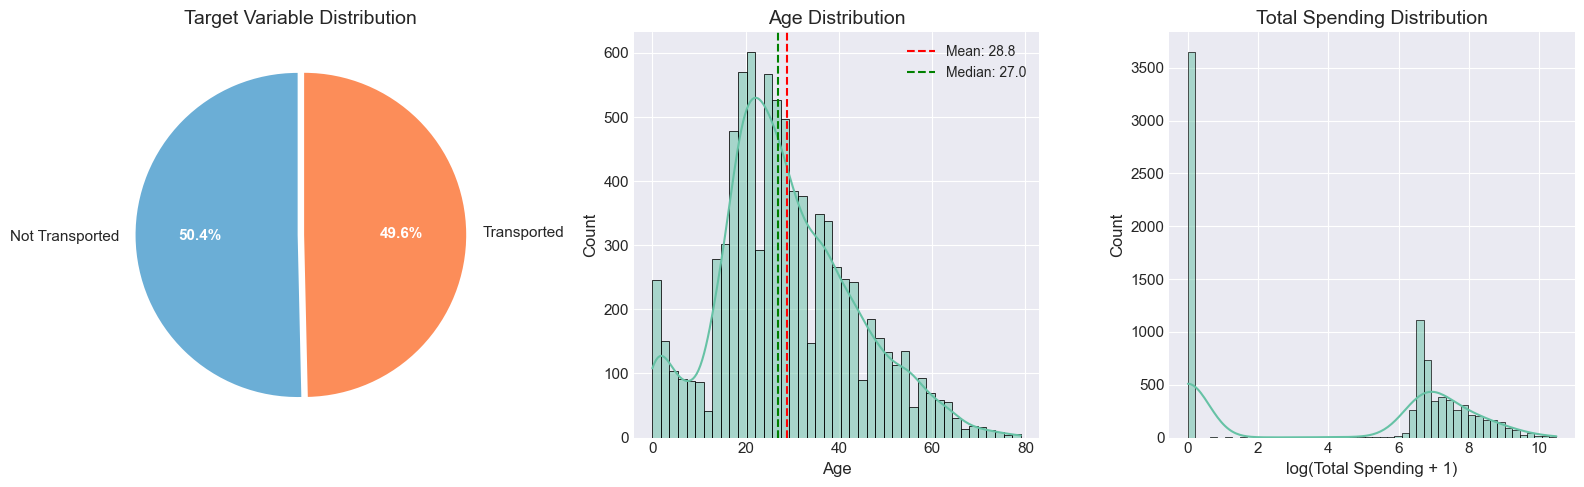

In [434]:
fig, axes = plt.subplots(1, 3, figsize = (16, 5))

colors = ['#6BAED6', '#FC8D59']
counts = train['Transported'].value_counts()
wedges, texts, autotexts = axes[0].pie(counts, labels=['Not Transported', 'Transported'], 
                                         autopct='%1.1f%%', colors=colors, startangle=90,
                                         explode=(0.02, 0.02))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[0].set_title('Target Variable Distribution')

sns.histplot(data=train, x='Age', kde=True, ax=axes[1])
axes[1].axvline(train['Age'].mean(), color='red', linestyle='--', label=f'Mean: {train["Age"].mean():.1f}')
axes[1].axvline(train['Age'].median(), color='green', linestyle='--', label=f'Median: {train["Age"].median():.1f}')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].legend()

spending_sum = train[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)
sns.histplot(np.log1p(spending_sum), bins=50, kde=True, ax=axes[2])
axes[2].set_title('Total Spending Distribution')
axes[2].set_xlabel('log(Total Spending + 1)')

plt.tight_layout()
plt.show()

Categorical variable analysis

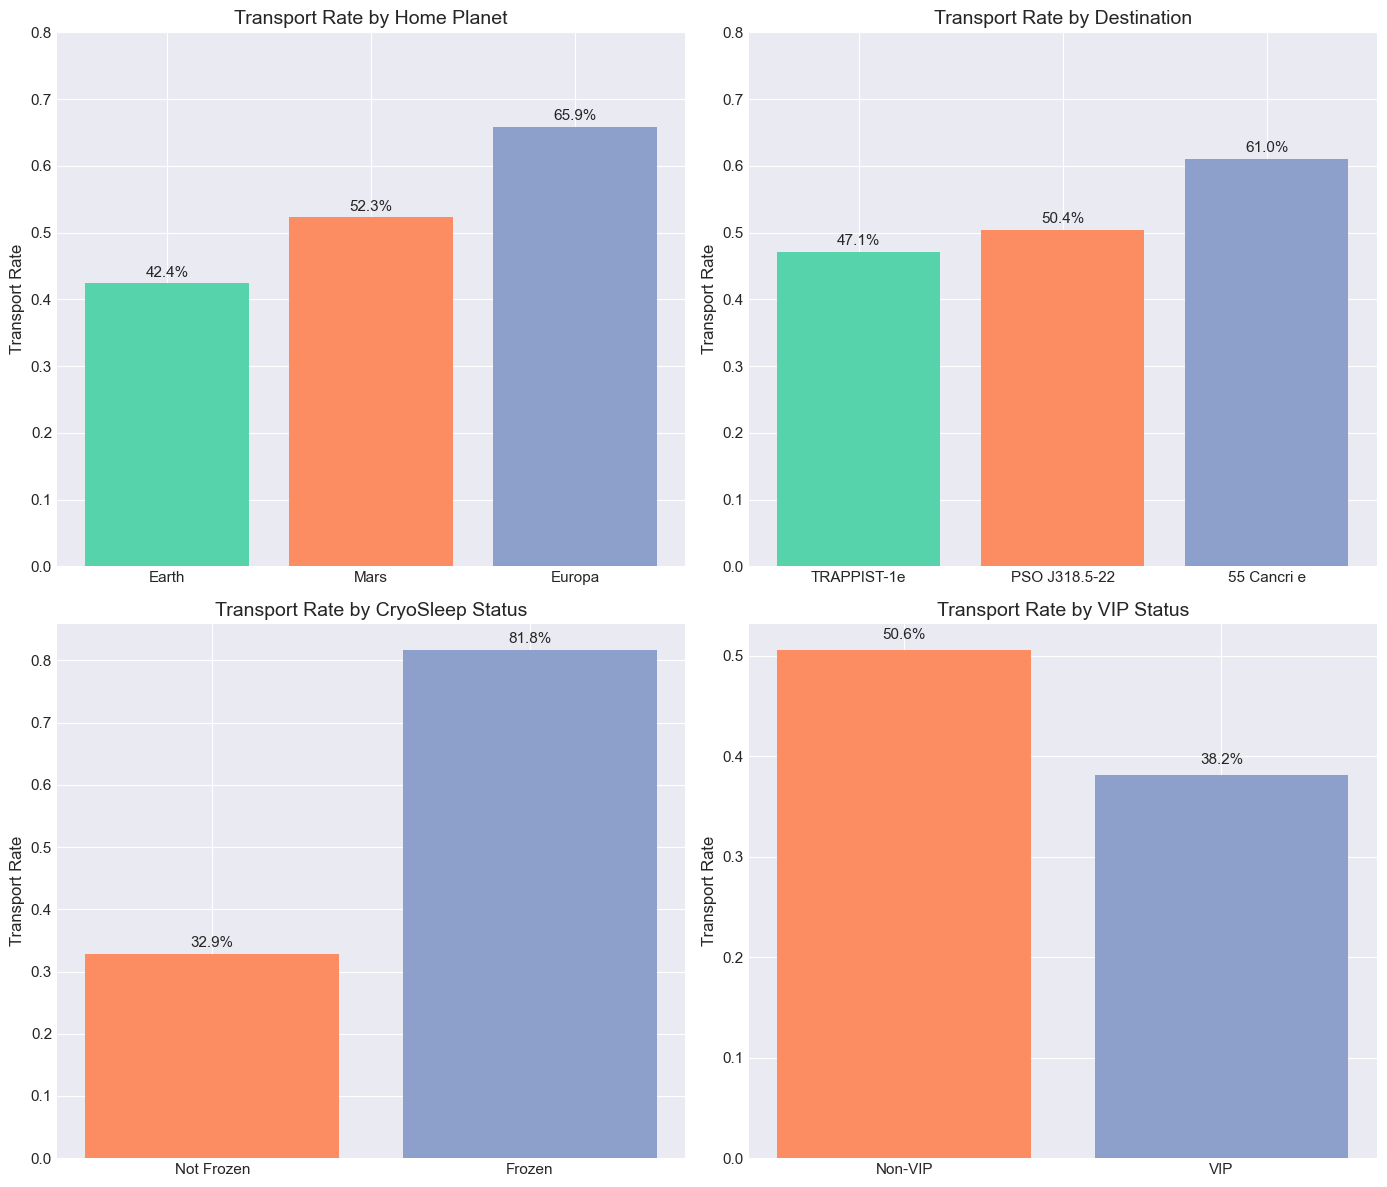

In [435]:
fig, axes = plt.subplots(2, 2, figsize = (14, 12))

homeplanet_tra = train.groupby('HomePlanet')['Transported'].mean().sort_values()
bars1 = axes[0,0].bar(homeplanet_tra.index, homeplanet_tra.values, color=['#57D3AC', '#FC8D62', '#8DA0CB'])
axes[0,0].set_title('Transport Rate by Home Planet')
axes[0,0].set_ylabel('Transport Rate')
axes[0,0].set_ylim(0, 0.8)
for bar, val in zip(bars1, homeplanet_tra.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

dest_tra = train.groupby('Destination')['Transported'].mean().sort_values()
bars2 = axes[0,1].bar(dest_tra.index, dest_tra.values, color=['#57D3AC', '#FC8D62', '#8DA0CB'])
axes[0,1].set_title('Transport Rate by Destination')
axes[0,1].set_ylabel('Transport Rate')
axes[0,1].set_ylim(0, 0.8)
for bar, val in zip(bars2, dest_tra.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

cryo_data = train.groupby('CryoSleep')['Transported'].mean()
bars3 = axes[1,0].bar(['Not Frozen', 'Frozen'], cryo_data.values, color=['#FC8D62', '#8DA0CB'])
axes[1,0].set_title('Transport Rate by CryoSleep Status')
axes[1,0].set_ylabel('Transport Rate')
for bar, val in zip(bars3, cryo_data.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

vip_data = train.groupby('VIP')['Transported'].mean()
bars4 = axes[1,1].bar(['Non-VIP', 'VIP'], vip_data.values, color=['#FC8D62', '#8DA0CB'])
axes[1,1].set_title('Transport Rate by VIP Status')
axes[1,1].set_ylabel('Transport Rate')
for bar, val in zip(bars4, vip_data.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', ha='center')

plt.tight_layout()
plt.show()

Missing value heatmap

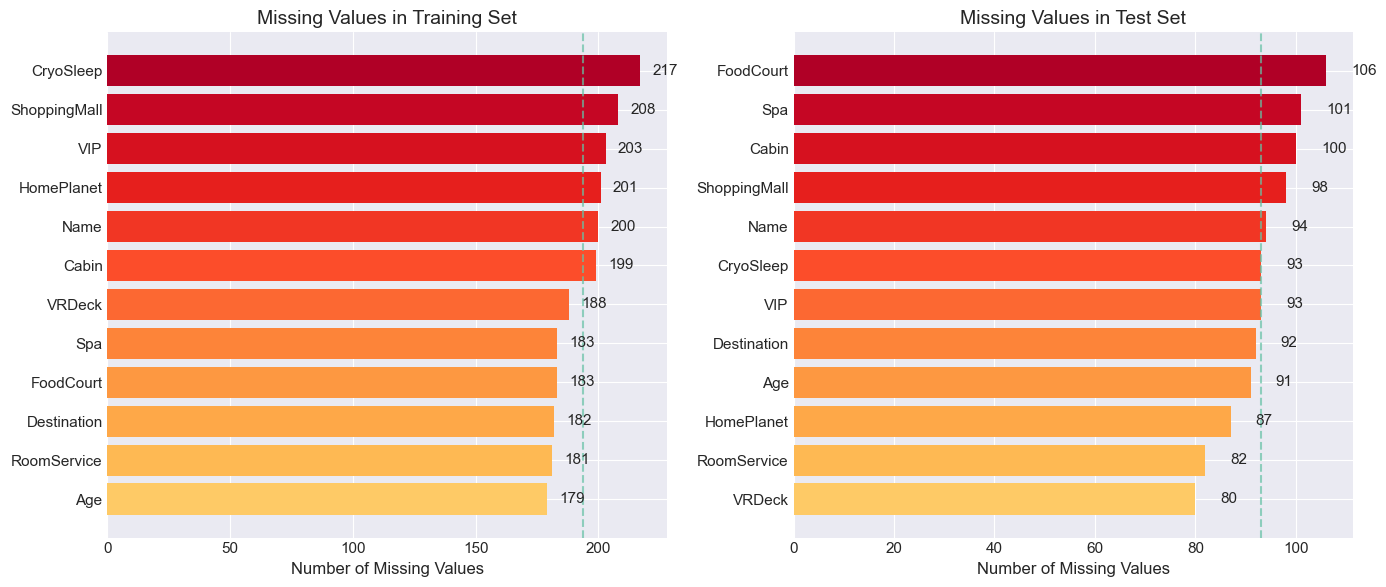

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(missing_train)))
bars1 = axes[0].barh(missing_train.index, missing_train.values, color=colors)
axes[0].set_title('Missing Values in Training Set')
axes[0].set_xlabel('Number of Missing Values')
for bar, val in zip(bars1, missing_train.values):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(val), va='center')

missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=True)
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(missing_test)))
bars2 = axes[1].barh(missing_test.index, missing_test.values, color=colors)
axes[1].set_title('Missing Values in Test Set')
axes[1].set_xlabel('Number of Missing Values')
for bar, val in zip(bars2, missing_test.values):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.show()

Spending characteristic relationship

C:\Users\admin\AppData\Local\Temp\ipykernel_35160\3070629134.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(spending_transported, labels=['Not Transported', 'Transported'], patch_artist=True, showmeans=True)


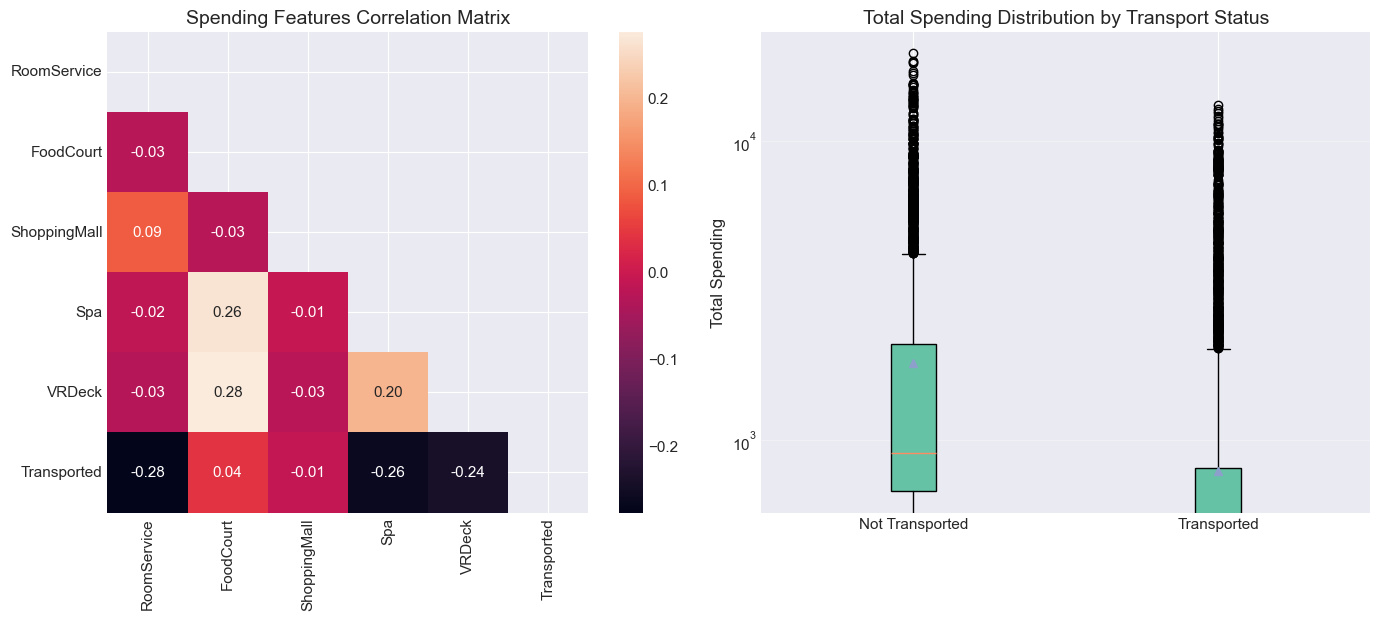

In [ ]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corr_matrix = train[spend_cols + ['Transported']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', square=True, ax=axes[0])
axes[0].set_title('Spending Features Correlation Matrix')

spending_sum = train[spend_cols].sum(axis=1)
spending_transported = [spending_sum[train['Transported'] == False], spending_sum[train['Transported'] == True]]
bp = axes[1].boxplot(spending_transported, labels=['Not Transported', 'Transported'], patch_artist=True, showmeans=True)

axes[1].set_title('Total Spending Distribution by Transport Status')
axes[1].set_ylabel('Total Spending')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Spending characteristics distribution

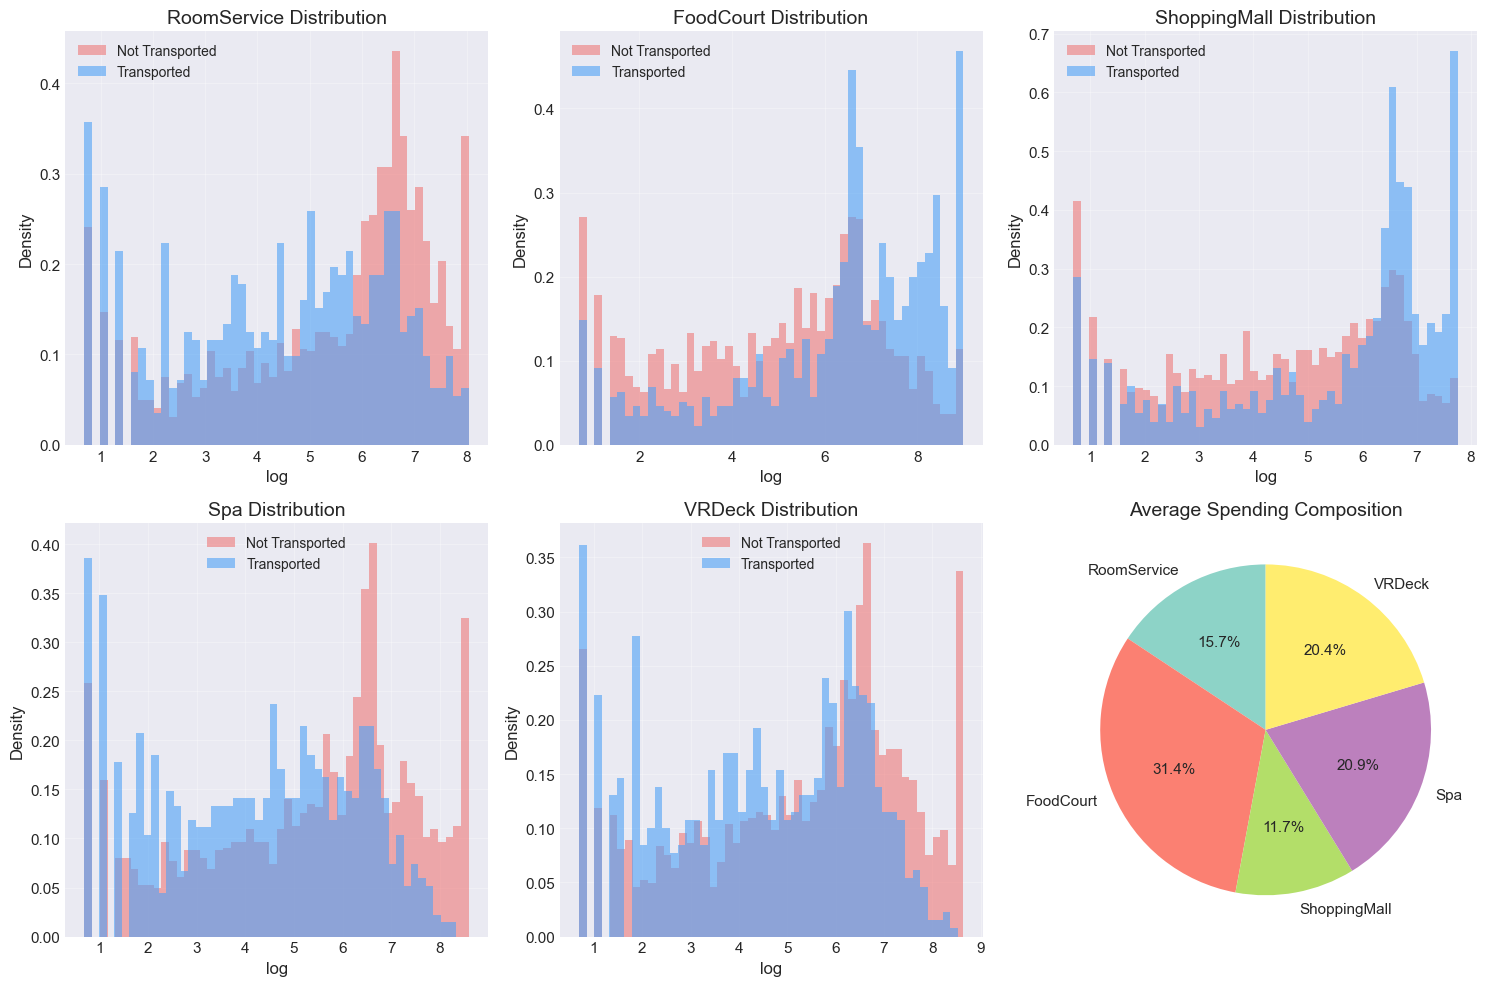

In [472]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(spend_cols):
    row, col_idx = idx // 3, idx % 3
    for transported, color, label in zip([False, True], ["#EF7979", "#4EA2F6"], ['Not Transported', 'Transported']):
        data = train[train['Transported'] == transported][col]
        data_clean = data[data > 0]
        if len(data_clean) > 0:
            axes[row, col_idx].hist(np.log1p(data_clean), bins=50, alpha=0.6, color=color, label=label, density=True)
    axes[row, col_idx].set_title(f'{col} Distribution')
    axes[row, col_idx].set_xlabel('log')
    axes[row, col_idx].set_ylabel('Density')
    axes[row, col_idx].legend()
    axes[row, col_idx].grid(alpha=0.3)

avg_spending = train[spend_cols].mean()
axes[1, 2].pie(avg_spending.values, labels=avg_spending.index, autopct='%1.1f%%',
               colors=plt.cm.Set3(np.linspace(0, 1, 5)), startangle=90)
axes[1, 2].set_title('Average Spending Composition')

plt.tight_layout()
plt.show()

Outlier detection

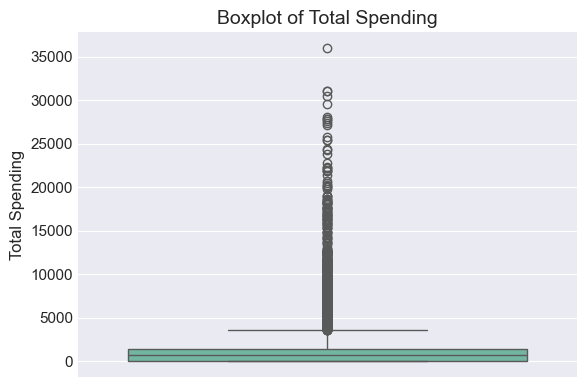

In [437]:
fig, ax = plt.subplots(figsize = (6, 4))
sns.boxplot(y=spending_sum, ax = ax)
ax.set_title('Boxplot of Total Spending')
ax.set_ylabel('Total Spending')
plt.tight_layout()
plt.show()

Feature engineering and data cleaning

In [438]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["GroupId"] = out["PassengerId"].astype(str).str.split("_").str[0]
    out["PassengerNo"] = pd.to_numeric(out["PassengerId"].astype(str).str.split("_").str[1], errors="coerce")
    out["GroupSize"] = out.groupby("GroupId")["PassengerId"].transform("count")
    out["IsSolo"] = (out["GroupSize"] == 1).astype(int)

    cabin = out["Cabin"].astype(str).str.split("/", expand = True)
    out["Deck"] = cabin[0].replace("nan", np.nan) if cabin.shape[1] > 0 else np.nan
    out["CabinNum"] = pd.to_numeric(cabin[1], errors = "coerce") if cabin.shape[1] > 1 else np.nan
    out["Side"] = cabin[2].replace("nan", np.nan) if cabin.shape[1] > 2 else np.nan

    out["Surname"] = out["Name"].astype(str).str.split(" ").str[-1].replace("nan", np.nan)
    out["FamilySizeApprox"] = out.groupby("Surname")["PassengerId"].transform("count")
    out.loc[out["Surname"].isna(), "FamilySizeApprox"] = np.nan
    out["NameLength"] = out["Name"].astype(str).str.len()

    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    for c in spend_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
        out[f"{c}_log1p"] = np.log1p(out[c].fillna(0))
        out[f"{c}_zero"] = (out[c].fillna(0) == 0).astype(int)
        out[f"{c}_missing"] = out[c].isna().astype(int)

    out["TotalSpend"] = out[spend_cols].sum(axis=1, skipna=True)
    out["TotalSpend_log1p"] = np.log1p(out["TotalSpend"].fillna(0))
    out["NoSpend"] = (out["TotalSpend"].fillna(0) == 0).astype(int)
    out["AnySpend"] = 1 - out["NoSpend"]

    out["LuxurySpend"] = out[["Spa", "VRDeck"]].sum(axis=1, skipna=True)
    out["BasicSpend"] = out[["RoomService", "FoodCourt", "ShoppingMall"]].sum(axis=1, skipna=True)
    out["LuxurySpend_log1p"] = np.log1p(out["LuxurySpend"].fillna(0))
    out["BasicSpend_log1p"] = np.log1p(out["BasicSpend"].fillna(0))
    out["LuxurySpendRatio"] = (out["LuxurySpend"] / out["TotalSpend"].replace(0, np.nan)).fillna(0)
    out["BasicSpendRatio"] = (out["BasicSpend"] / out["TotalSpend"].replace(0, np.nan)).fillna(0)

    out["TotalSpendBin"] = pd.cut(
        out["TotalSpend"],
        bins=[-1, 0, 100, 500, 1500, 4000, 100000],
        labels=["zero", "low", "medium", "high", "very_high", "extreme"],
    ).astype(str).replace("nan", np.nan)

    out["Age"] = pd.to_numeric(out["Age"], errors="coerce")
    out["AgeMissing"] = out["Age"].isna().astype(int)
    out["AgeBin"] = pd.cut(
        out["Age"],
        bins=[-1, 5, 12, 18, 25, 35, 50, 65, 100],
        labels=["baby", "child", "teen", "young", "adult", "middle", "senior", "elder"],
    ).astype(str).replace("nan", np.nan)
    out["IsChild"] = (out["Age"].fillna(999) < 13).astype(int)
    out["IsTeen"] = ((out["Age"].fillna(-1) >= 13) & (out["Age"].fillna(-1) < 18)).astype(int)

    for b in ["CryoSleep", "VIP"]:
        out[f"{b}_int"] = out[b].astype(str).str.lower().map({"true": 1, "false": 0}).fillna(-1).astype(int)
        out[f"{b}_missing"] = out[b].isna().astype(int)

    out["Cryo_NoSpend"] = ((out["CryoSleep_int"] == 1) & (out["NoSpend"] == 1)).astype(int)
    out["Awake_NoSpend"] = ((out["CryoSleep_int"] == 0) & (out["NoSpend"] == 1)).astype(int)
    out["Cryo_WithSpend"] = ((out["CryoSleep_int"] == 1) & (out["AnySpend"] == 1)).astype(int)
    out["Awake_HighLuxury"] = ((out["CryoSleep_int"] == 0) & (out["LuxurySpend"] > out["LuxurySpend"].median())).astype(int)

    out["Deck_Side"] = out["Deck"].astype(str) + "_" + out["Side"].astype(str)
    out["HomePlanet_Deck"] = out["HomePlanet"].astype(str) + "_" + out["Deck"].astype(str)
    out["HomePlanet_Destination"] = out["HomePlanet"].astype(str) + "_" + out["Destination"].astype(str)
    out["Destination_Deck"] = out["Destination"].astype(str) + "_" + out["Deck"].astype(str)
    out["Cryo_Deck"] = out["CryoSleep"].astype(str) + "_" + out["Deck"].astype(str)
    out["Cryo_Destination"] = out["CryoSleep"].astype(str) + "_" + out["Destination"].astype(str)
    out["Side_Destination"] = out["Side"].astype(str) + "_" + out["Destination"].astype(str)
    out["Planet_Side"] = out["HomePlanet"].astype(str) + "_" + out["Side"].astype(str)
    out["Planet_Cryo"] = out["HomePlanet"].astype(str) + "_" + out["CryoSleep"].astype(str)
    out["Deck_SpendBin"] = out["Deck"].astype(str) + "_" + out["TotalSpendBin"].astype(str)

    return out

def build_full_features(train, test):
    train_x = train.drop(columns=["Transported"]).copy()
    full = pd.concat([train_x, test.copy()], axis=0, ignore_index=True)
    full_fe = add_features(full)
    train_fe = full_fe.iloc[:len(train_x)].reset_index(drop=True)
    test_fe = full_fe.iloc[len(train_x):].reset_index(drop=True)
    return train_fe, test_fe

train_fe, test_fe = build_full_features(train, test)

drop_cols = ["PassengerId", "Name", "Cabin", "GroupId", "Surname"]
for df in [train_fe, test_fe]:
    for c in drop_cols:
        if c in df.columns:
            df.drop(columns=[c], inplace=True)


Data preprocessing

In [439]:
def ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=5, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_full_features(train, test):
    train_x = train.drop(columns=["Transported"]).copy()
    full = pd.concat([train_x, test.copy()], axis=0, ignore_index=True)
    full_fe = add_features(full)
    train_fe = full_fe.iloc[:len(train_x)].reset_index(drop=True)
    test_fe = full_fe.iloc[len(train_x):].reset_index(drop=True)
    return train_fe, test_fe

def oof_target_encoding(train_fe, test_fe, y, cols, smoothing=20.0):
    train_out = train_fe.copy()
    test_out = test_fe.copy()
    global_mean = float(y.mean())
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for col in cols:
        if col not in train_out.columns:
            continue

        new_col = f"TE_{col}"
        train_out[new_col] = global_mean

        for tr_idx, va_idx in skf.split(train_out, y):
            tmp = pd.DataFrame({col: train_out.iloc[tr_idx][col], "y": y.iloc[tr_idx]})
            stats = tmp.groupby(col, dropna=False)["y"].agg(["mean", "count"])
            smooth = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
            train_out.loc[va_idx, new_col] = train_out.iloc[va_idx][col].map(smooth).fillna(global_mean).values

        full_tmp = pd.DataFrame({col: train_out[col], "y": y})
        stats = full_tmp.groupby(col, dropna=False)["y"].agg(["mean", "count"])
        smooth = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
        test_out[new_col] = test_out[col].map(smooth).fillna(global_mean)

    return train_out, test_out

def split_cols(X):
    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in X.columns if c not in num_cols]
    return num_cols, cat_cols

def make_preprocessor(X):
    num_cols, cat_cols = split_cols(X)
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe()),
        ]), cat_cols),
    ], remainder="drop")

preprocessor = make_preprocessor(train_fe)

X = preprocessor.fit_transform(train_fe)
test = preprocessor.transform(test_fe)
y = y_train_raw.values

In [440]:
def detect_outliers(df, cols, threshold=3):
    outliers = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR
        outliers[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    return outliers

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
outliers = detect_outliers(train, spend_cols)

def winsorize_series(s, limits=(0.01, 0.99)):
    lower = s.quantile(limits[0])
    upper = s.quantile(limits[1])
    return s.clip(lower, upper)

for col in spend_cols:
    train[col] = winsorize_series(train[col])

Train-test split

In [441]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y)

In [442]:
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000, random_state = RANDOM_STATE),
    'SVM': SVC(random_state = RANDOM_STATE, probability = True),
    'Random Forest': RandomForestClassifier(n_estimators = 100, random_state = RANDOM_STATE, n_jobs = -1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 100, random_state = RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(n_estimators = 100, random_state = RANDOM_STATE, n_jobs = -1),
    'AdaBoost': AdaBoostClassifier(n_estimators = 100, random_state = RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors = 5),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(n_estimators = 100, random_state = RANDOM_STATE, use_label_encoder = False, eval_metric = 'logloss'),
    'LightGBM': LGBMClassifier(n_estimators = 100, random_state = RANDOM_STATE, verbose = -1)
}

Cross-validation score

In [443]:
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv = 3, scoring='accuracy', n_jobs = -1)
    cv_results[name] = {
        'mean_accuracy': scores.mean(),
        'std_accuracy': scores.std(),
        'scores': scores
    }
    print(f"{name:25} | Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic Regression       | Accuracy: 0.7964 +/- 0.0062
SVM                       | Accuracy: 0.7886 +/- 0.0076
Random Forest             | Accuracy: 0.7982 +/- 0.0068
Gradient Boosting         | Accuracy: 0.8085 +/- 0.0086
Extra Trees               | Accuracy: 0.7867 +/- 0.0036
AdaBoost                  | Accuracy: 0.7947 +/- 0.0090
KNN                       | Accuracy: 0.7645 +/- 0.0105
Naive Bayes               | Accuracy: 0.7570 +/- 0.0041
XGBoost                   | Accuracy: 0.7998 +/- 0.0068
LightGBM                  | Accuracy: 0.8086 +/- 0.0023


Hyperparameter tuning for Logistic Regression

In [444]:
lr_param_grid = {
    'C': [0.01, 0.1, 1],
    'l1_ratio': [0.0, 1.0],
    'solver': ['liblinear',  'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter = 1000, random_state = 42),
    lr_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

lr_grid.fit(X_train, y_train)

lr_best = lr_grid.best_estimator_

print(f"Best parameters: {lr_grid.best_params_}\n")
print(f"Best cross-validation score: {lr_grid.best_score_}\n")

Best parameters: {'C': 1, 'l1_ratio': 1.0, 'solver': 'liblinear'}

Best cross-validation score: 0.8045732845786635



Hyperparameter tuning for SVM

In [445]:
svm_param_grid = {
    'C': [10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    SVC(random_state = 42),
    svm_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

svm_grid.fit(X_train, y_train)

svm_best = svm_grid.best_estimator_

print(f"Best parameters: {svm_grid.best_params_}\n")
print(f"Best cross-validation score: {svm_grid.best_score_}\n")


Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best cross-validation score: 0.7858785925968068



Hyperparameter tuning for Random Tree

In [446]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state = RANDOM_STATE, n_jobs = -1),
    rf_param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs = -1
)

rf_grid.fit(X_train, y_train)

models['Random Forest'] = rf_grid.best_estimator_

print(f"Best parameters: {rf_grid.best_params_}\n")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}\n")


Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Best cross-validation score: 0.8050



Hyperparameter tuning for Gradient Boosting

In [447]:
gb_param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state = RANDOM_STATE),
    gb_param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs = -1
)

gb_grid.fit(X_train, y_train)

models['Gradient Boosting'] = gb_grid.best_estimator_

print(f"Best parameters: {gb_grid.best_params_}\n")
print(f"Best cross-validation score: {gb_grid.best_score_:.4f}\n")

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Best cross-validation score: 0.8075



Hyperparameter tuning for XGBoost

In [448]:
xgb_param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state = RANDOM_STATE, eval_metric='logloss'),
    xgb_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

xgb_grid.fit(X_train, y_train)

models['XGBoost'] = xgb_grid.best_estimator_

print(f"Best parameters: {xgb_grid.best_params_}\n")
print(f"Best cross-validation score: {xgb_grid.best_score_:.4f}\n")

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Best cross-validation score: 0.8118



Hyperparameter tuning for LightGBM

In [449]:
lgb_param_grid = {
    'n_estimators': [200],
    'learning_rate': [0.05],
    'num_leaves': [31]
}

lgb_grid = GridSearchCV(
    LGBMClassifier(random_state = RANDOM_STATE, verbose = -1),
    lgb_param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs = -1
)

lgb_grid.fit(X_train, y_train)

models['LightGBM'] = lgb_grid.best_estimator_

print(f"Best parameters: {lgb_grid.best_params_}")
print(f"Best cross-validation score: {lgb_grid.best_score_:.4f}")

Best parameters: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}
Best cross-validation score: 0.8112


Model training and evaluation

Logistic Regression: Accuracy: 0.8005 | Precision: 0.7969 | Recall: 0.8105 | F1: 0.8036


d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


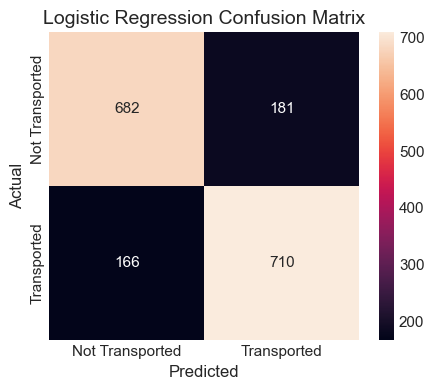

SVM: Accuracy: 0.7982 | Precision: 0.7654 | Recall: 0.8642 | F1: 0.8118


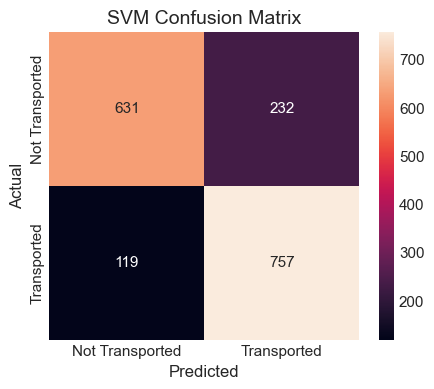

Random Forest: Accuracy: 0.8045 | Precision: 0.8004 | Recall: 0.8151 | F1: 0.8077


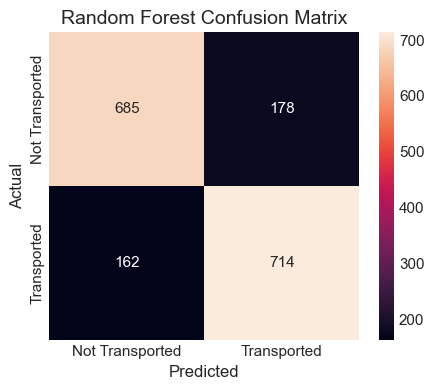

Gradient Boosting: Accuracy: 0.8177 | Precision: 0.8165 | Recall: 0.8231 | F1: 0.8198
Extra Trees: Accuracy: 0.8062 | Precision: 0.8340 | Recall: 0.7683 | F1: 0.7998
AdaBoost: Accuracy: 0.7993 | Precision: 0.7788 | Recall: 0.8402 | F1: 0.8083
KNN: Accuracy: 0.7711 | Precision: 0.7587 | Recall: 0.8002 | F1: 0.7789
Naive Bayes: Accuracy: 0.7481 | Precision: 0.8008 | Recall: 0.6655 | F1: 0.7269
XGBoost: Accuracy: 0.8125 | Precision: 0.8132 | Recall: 0.8151 | F1: 0.8141
LightGBM: Accuracy: 0.8154 | Precision: 0.8216 | Recall: 0.8094 | F1: 0.8154


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [450]:
performance_results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division = 0)
    rec = recall_score(y_test, y_pred, zero_division = 0)
    f1 = f1_score(y_test, y_pred, zero_division = 0)
    auc = roc_auc_score(y_test, y_pred) if y_pred_proba is not None else np.nan
    
    performance_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    }
    
    print(f"{name}: Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    if list(performance_results.keys()).index(name) < 3:
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize = (5, 4))
        sns.heatmap(cm, annot = True, fmt = 'd', 
                    xticklabels=["Not Transported", "Transported"],
                    yticklabels=["Not Transported", "Transported"])
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

Model performance comparison

In [451]:
print("Performance comparison:")
performance = pd.DataFrame(performance_results).T.round(4)
print(performance)

Performance comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8005     0.7969  0.8105    0.8036   0.8004
SVM                    0.7982     0.7654  0.8642    0.8118   0.7977
Random Forest          0.8045     0.8004  0.8151    0.8077   0.8044
Gradient Boosting      0.8177     0.8165  0.8231    0.8198   0.8177
Extra Trees            0.8062     0.8340  0.7683    0.7998   0.8065
AdaBoost               0.7993     0.7788  0.8402    0.8083   0.7990
KNN                    0.7711     0.7587  0.8002    0.7789   0.7709
Naive Bayes            0.7481     0.8008  0.6655    0.7269   0.7488
XGBoost                0.8125     0.8132  0.8151    0.8141   0.8125
LightGBM               0.8154     0.8216  0.8094    0.8154   0.8155


Feature importance analysis


Random Forest Top 10 feature importance:

                feature  importance
  num__LuxurySpendRatio    0.048226
cat__TotalSpendBin_zero    0.042072
          num__AnySpend    0.040853
           num__NoSpend    0.038306
 num__LuxurySpend_log1p    0.038249
   num__BasicSpendRatio    0.036980
        num__BasicSpend    0.034662
       num__LuxurySpend    0.033746
        num__TotalSpend    0.032887
  num__BasicSpend_log1p    0.031991

Gradient Boosting Top 10 feature importance:

                    feature  importance
              num__AnySpend    0.159944
            num__TotalSpend    0.116047
      num__LuxurySpendRatio    0.076472
     num__RoomService_log1p    0.067152
              num__CabinNum    0.055201
           num__RoomService    0.049547
    cat__TotalSpendBin_zero    0.035989
       num__BasicSpendRatio    0.034447
      cat__HomePlanet_Earth    0.033446
cat__HomePlanet_Deck_Mars_E    0.032472

XGBoost Top 10 feature importance:

                    feature  importan

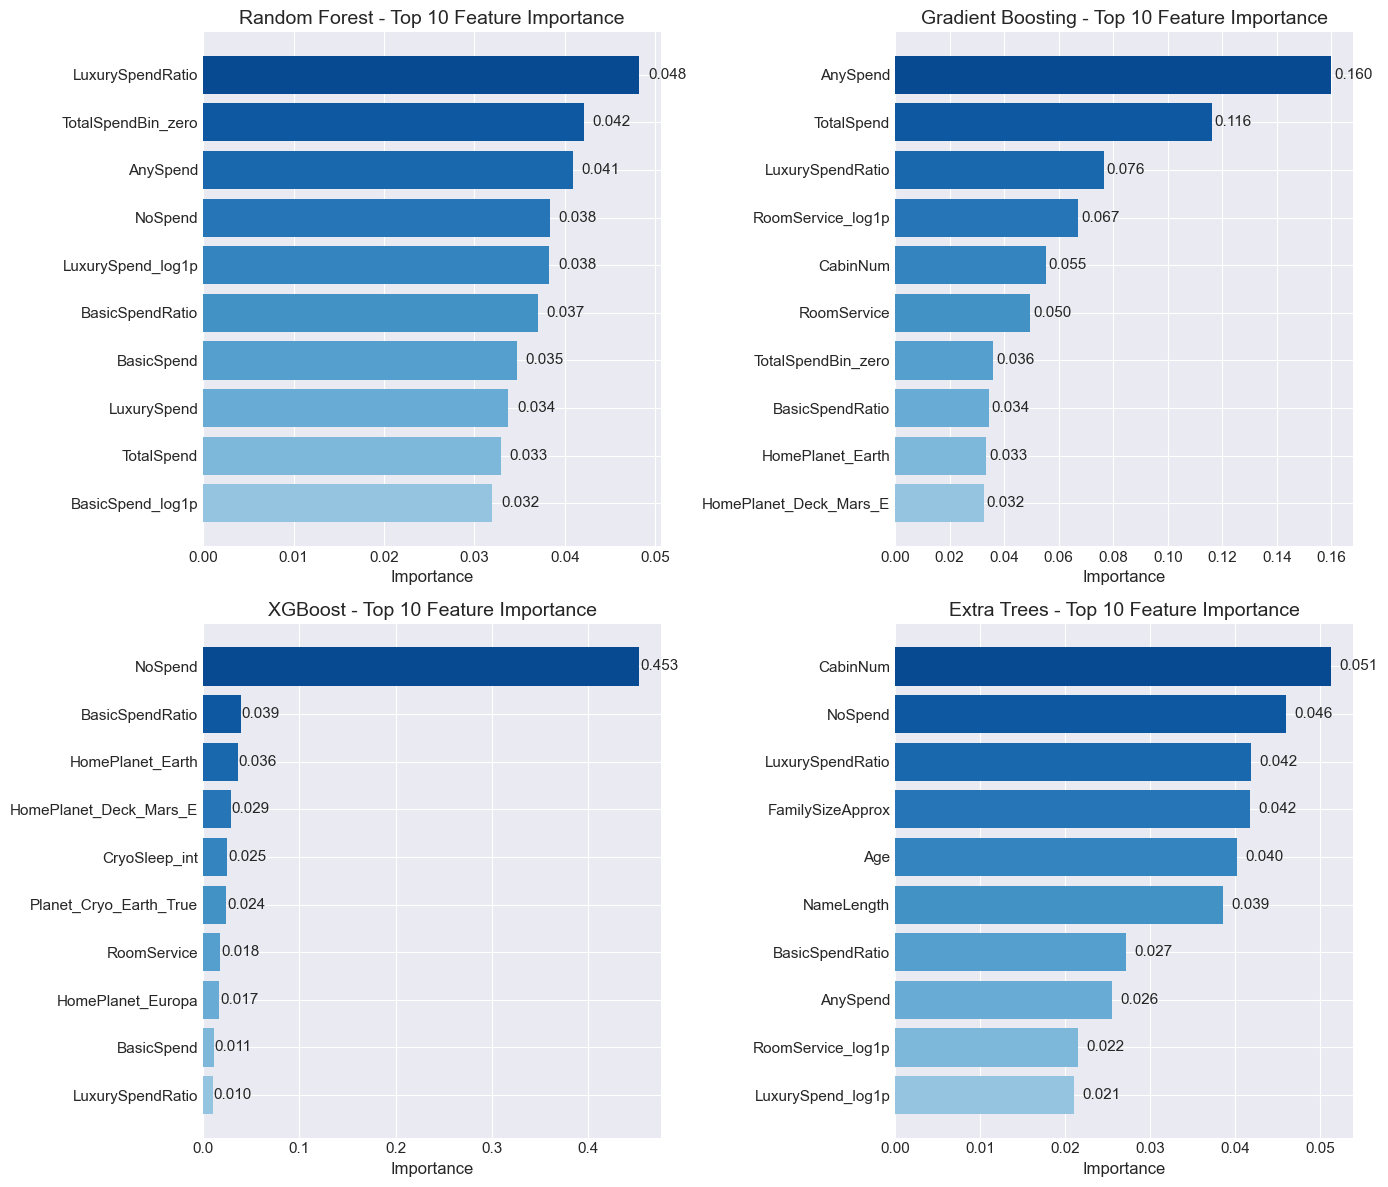

d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


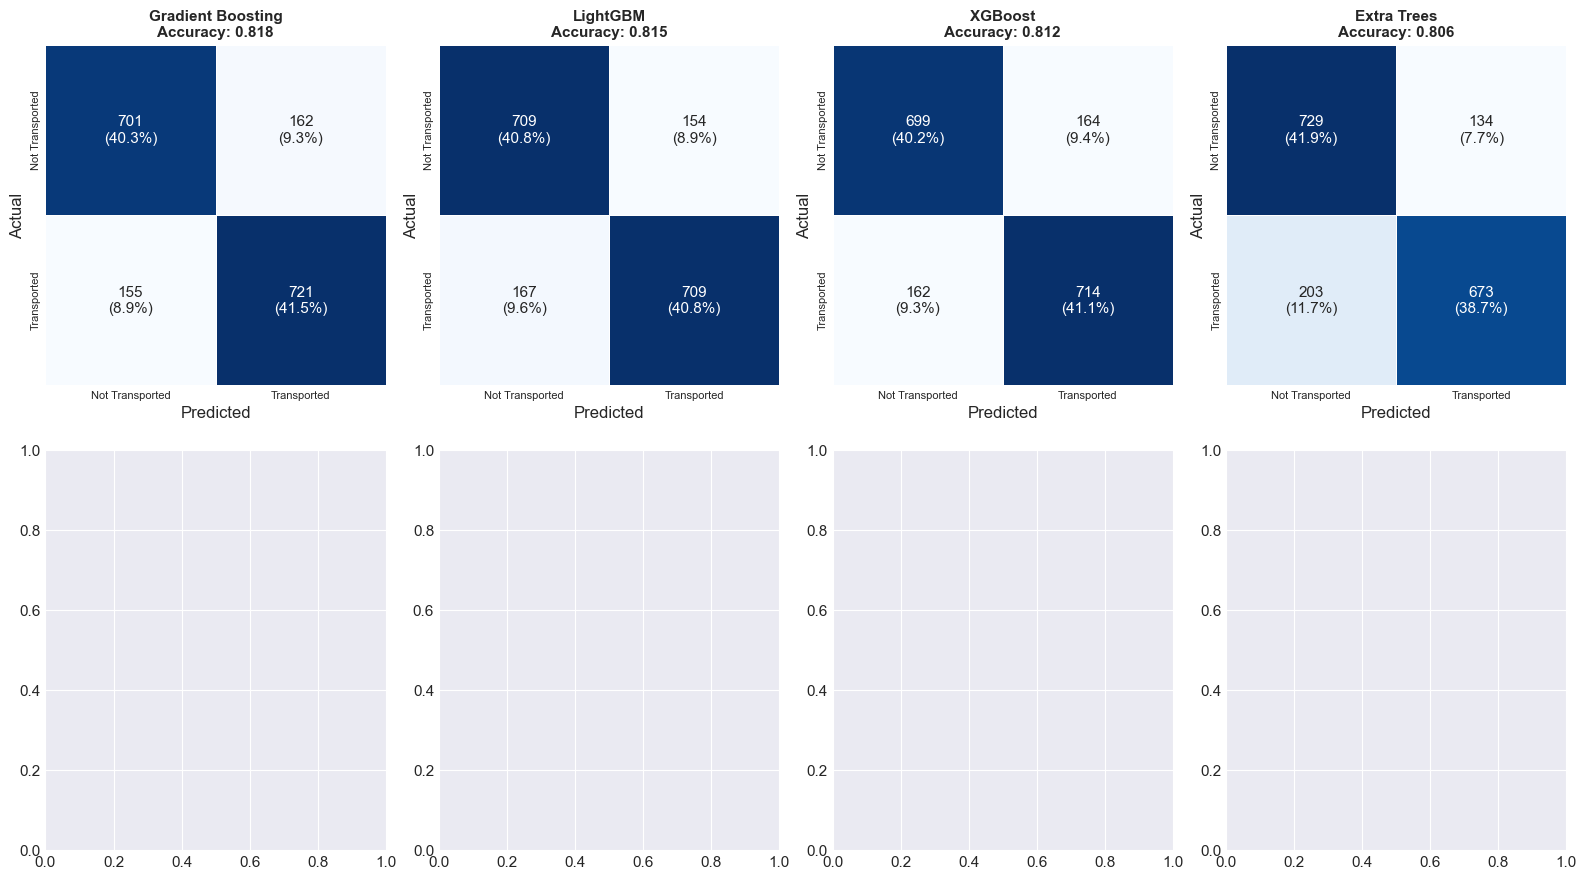

In [ ]:
feature_names = []

if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = preprocessor.get_feature_names_out().tolist()
elif hasattr(preprocessor, 'get_feature_names'):
    feature_names = preprocessor.get_feature_names().tolist()
    for name, transformer, columns in preprocessor.transformers_:
        if transformer == 'drop' or transformer is None:
            continue
        if hasattr(transformer, 'get_feature_names_out'):
            trans_features = transformer.get_feature_names_out(columns)
        elif hasattr(transformer, 'get_feature_names'):
            trans_features = transformer.get_feature_names(columns)
        else:
            if name == 'num':
                trans_features = columns
            else:
                trans_features = [f"{name}_{i}" for i in range(len(columns))]
        feature_names.extend(trans_features)

tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Extra Trees']
feature_importance_dict = {}

for name in tree_models:
    if name in trained_models:
        model = trained_models[name]
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            
            imp_df = pd.DataFrame({
                'feature': feature_names[:len(importances)],
                'importance': importances
            }).sort_values('importance', ascending = False).head(15)
            
            feature_importance_dict[name] = imp_df
            
            print(f"\n{name} Top 10 feature importance:\n")
            print(imp_df.head(10).to_string(index=False))

if len(feature_importance_dict) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    ax_list = axes.flatten()
    
    for idx, (name, imp_df) in enumerate(feature_importance_dict.items()):
        if idx < 4:
            imp_df['feature_clean'] = imp_df['feature'].str.replace('num__', '').str.replace('cat__', '')
            imp_df_display = imp_df.head(10).iloc[::-1]
            
            colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_df_display)))
            bars = ax_list[idx].barh(imp_df_display['feature_clean'], imp_df_display['importance'], color=colors)
            ax_list[idx].set_title(f'{name} - Top 10 Feature Importance')
            ax_list[idx].set_xlabel('Importance')
            
            for bar, val in zip(bars, imp_df_display['importance']):
                ax_list[idx].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()

Computational cost comparison

In [453]:
computational_results = {}

for name, model in list(trained_models.items()):
    print(f"{name}:\n")
    
    tracemalloc.start()
    gc.collect()
    
    snapshot1 = tracemalloc.take_snapshot()
    
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    snapshot2 = tracemalloc.take_snapshot()
    
    start_time = time.time()
    for _ in range(10):
        model.predict(X_test)
    inference_time = (time.time() - start_time) / 100
    
    stat_diff = snapshot2.compare_to(snapshot1, 'lineno')
    mem_allocated = sum(stat.size for stat in stat_diff if stat.size > 0) / 1024 / 1024
    
    tracemalloc.stop()
    
    computational_results[name] = {
        'Training Time (s)': training_time,
        'Inference Time (ms)': inference_time * 1000,
        'Memory Allocated (MB)': mem_allocated
    }
    
    print(f"{name:30} Train: {training_time:.4f}s | Infer: {inference_time*1000:.2f}ms | Memory Alloc: {mem_allocated:.2f}MB")

Logistic Regression:



d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression            Train: 0.8920s | Infer: 0.04ms | Memory Alloc: 0.08MB
SVM:

SVM                            Train: 9.1878s | Infer: 59.35ms | Memory Alloc: 7.55MB
Random Forest:

Random Forest                  Train: 0.4707s | Infer: 4.27ms | Memory Alloc: 0.26MB
Gradient Boosting:

Gradient Boosting              Train: 5.0458s | Infer: 0.30ms | Memory Alloc: 0.06MB
Extra Trees:

Extra Trees                    Train: 0.3482s | Infer: 3.93ms | Memory Alloc: 0.26MB
AdaBoost:

AdaBoost                       Train: 1.9971s | Infer: 7.72ms | Memory Alloc: 0.15MB
KNN:

KNN                            Train: 0.0025s | Infer: 3.30ms | Memory Alloc: 0.06MB
Naive Bayes:

Naive Bayes                    Train: 0.0163s | Infer: 0.51ms | Memory Alloc: 0.01MB
XGBoost:

XGBoost                        Train: 0.1628s | Infer: 0.12ms | Memory Alloc: 0.02MB
LightGBM:

LightGBM                       Train: 0.2325s | Infer: 0.55ms | Memory Alloc: 0.03MB


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names

C:\Users\admin\AppData\Local\Temp\ipykernel_35160\115127813.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[1].annotate(name, (train_times[i], accuracies[i]), xytext=(5, 5), textcoords='offset points')


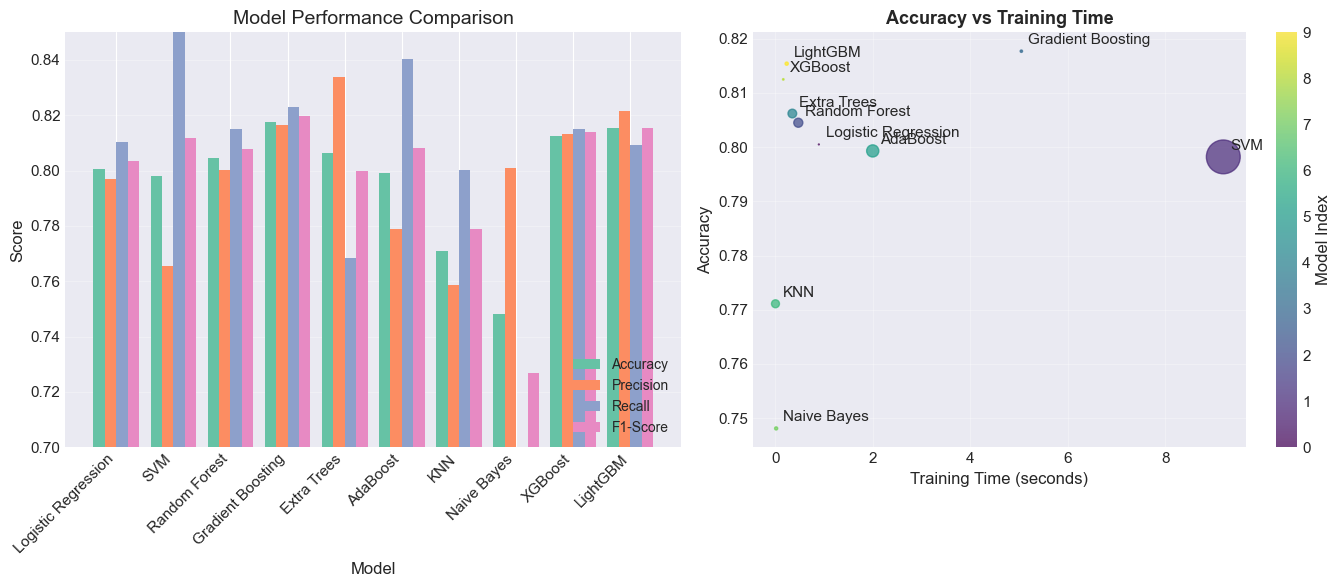

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(performance))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, performance[metric], width, label=metric)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(performance.index, rotation=45, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.7, 0.85)
axes[0].grid(axis='y', alpha=0.3)

time_data = pd.DataFrame(computational_results).T
model_names = time_data.index
accuracies = [performance.loc[name, 'Accuracy'] for name in model_names]
train_times = time_data['Training Time (s)']
sizes = time_data['Inference Time (ms)'] * 10

scatter = axes[1].scatter(train_times, accuracies, s=sizes, alpha=0.7, c=range(len(model_names)), cmap='viridis')

for i, name in enumerate(model_names):
    axes[1].annotate(name, (train_times[i], accuracies[i]), xytext=(5, 5), textcoords='offset points')

axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Training Time')
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Model Index')

plt.tight_layout()
plt.show()

Prediction result

In [454]:
best_model_name = performance['Accuracy'].idxmax()
best_model = trained_models[best_model_name]

prediction = best_model.predict(test)
submission = pd.DataFrame({
    'PassengerId': PassengerId,
    'Transported': prediction.astype(bool)
})

submission.to_csv('submission.csv', index = False)